# MNIST Dataset ML Project
Dataset from [Here]()

## Setup

### Import Packages

In [71]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm.auto import tqdm
import pathlib as Path 
#import torch.nn as nn
import numpy as np
import torchvision
import torch

### MNIST Dataset Processing Pipeline

#### Import Data

In [4]:
# May have to do a lot of different stuff, load from dataset, normalize (lookup what that means), load both the train and the test sets, etc.

training_data = torchvision.datasets.MNIST(
    root="data",
    train=True,
    download=True,
    #transform= #Look up what this is doing to the data in a little
)


test_data = torchvision.datasets.MNIST(
    root="data",
    train=False,
    download=True,
    #transform= #Look up what this is doing to the data in a little
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.61MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.49MB/s]


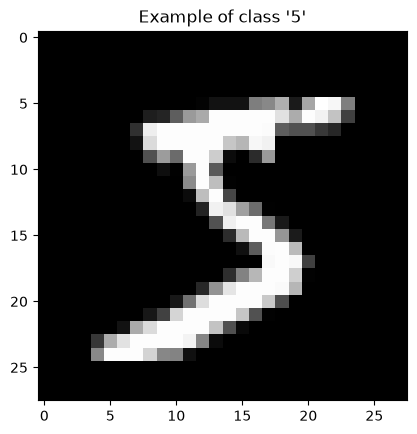

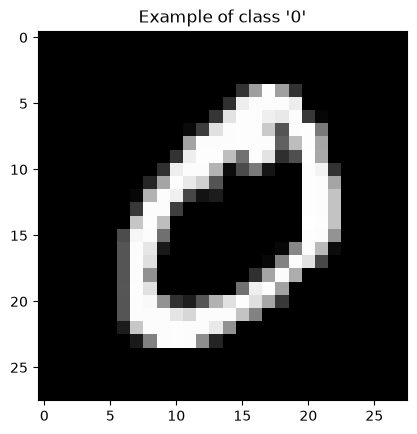

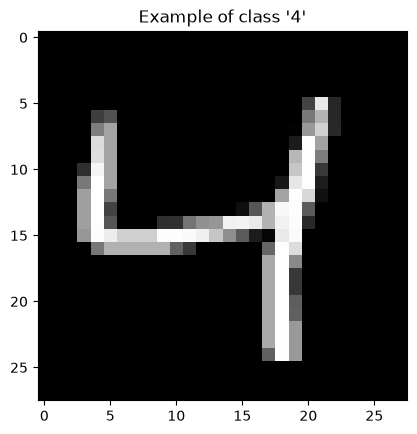

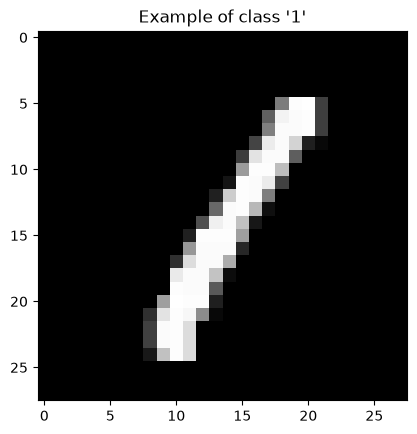

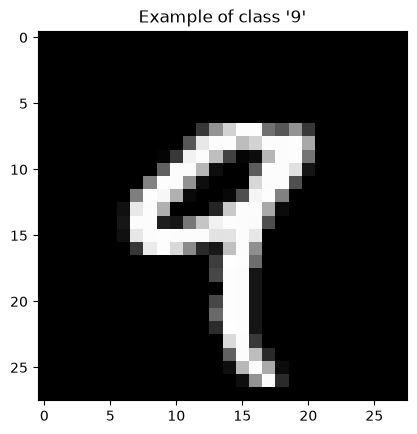

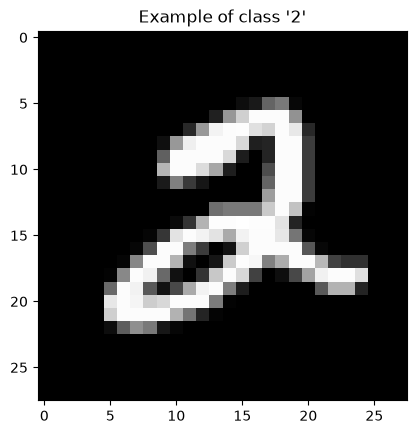

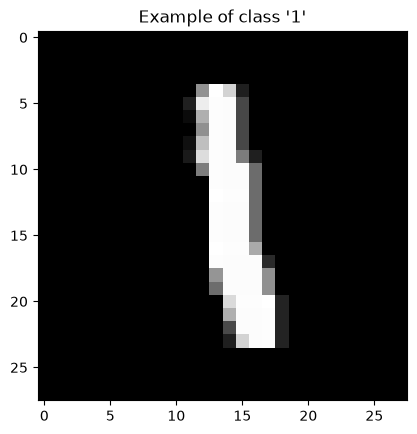

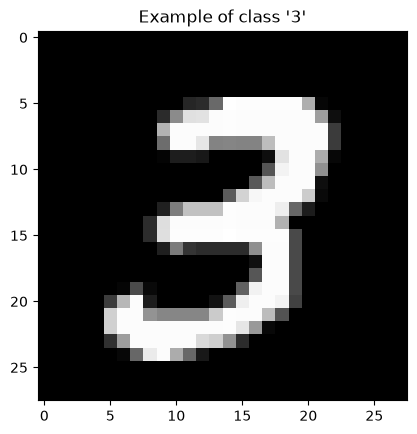

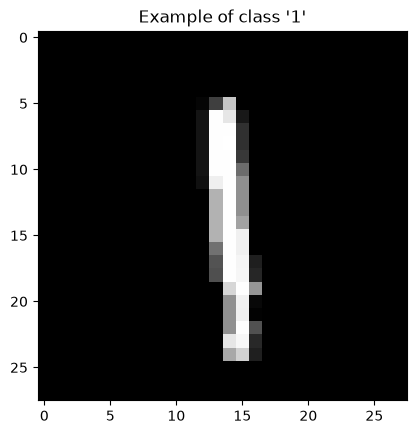

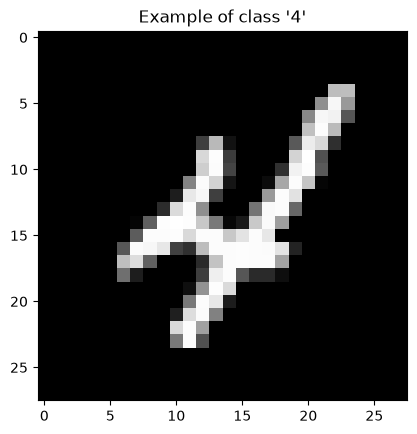

In [32]:

for i in range(10):
    plt.imshow(training_data[i][0], cmap='grey')
    plt.title(f"Example of class '{training_data[i][1]}'")
    plt.show()
#print(training_data[0][1])

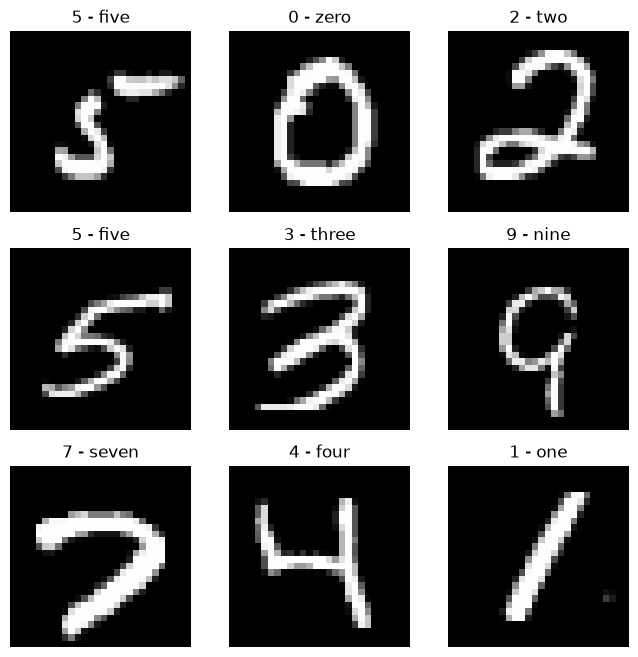

In [ ]:
labels_map = training_data.classes

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img, cmap="gray")
plt.show()

#### Etc... (Validation, Padding if necessary, Showing examples, Printing out names of all available classes)

In [34]:
training_data.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [46]:
len(training_data)

60000

In [62]:
CLASSES = training_data.class_to_idx

print(list(CLASSES))

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [69]:
print(training_data[0][1])

5


In [33]:
help(training_data)

Help on MNIST in module torchvision.datasets.mnist object:

class MNIST(torchvision.datasets.vision.VisionDataset)
 |  MNIST(
 |      root: Union[str, Path],
 |      train: bool = True,
 |      transform: Optional[Callable] = None,
 |      target_transform: Optional[Callable] = None,
 |      download: bool = False
 |  ) -> None
 |
 |  `MNIST <http://yann.lecun.com/exdb/mnist/>`_ Dataset.
 |
 |  Args:
 |      root (str or ``pathlib.Path``): Root directory of dataset where ``MNIST/raw/train-images-idx3-ubyte``
 |          and  ``MNIST/raw/t10k-images-idx3-ubyte`` exist.
 |      train (bool, optional): If True, creates dataset from ``train-images-idx3-ubyte``,
 |          otherwise from ``t10k-images-idx3-ubyte``.
 |      transform (callable, optional): A function/transform that  takes in a PIL image
 |          and returns a transformed version. E.g, ``transforms.RandomCrop``
 |      target_transform (callable, optional): A function/transform that takes in the
 |          target and tran

## Modelling Data

### Setting Up Layer Architecture (Defining the NN)
Based on the following architecture:

![image](https://docs.pytorch.org/tutorials/_images/mnist.png)

In [ ]:
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__() # Import methods from inherited class

        ## Will take in our 32x32 image and output 6 feature maps of 32-5+1 = 28; 
        #   -5 is the kernel size, and +1 is for the first 5x5 convolution / starting map, 
        #   This along both axes yields 6 resulting (images) feature maps of 28x28
        self.conv_1 = torch.nn.Conv2D(in_channels=1, # Base single image is taken in,
                                      out_channels=6, # 6 Separate kernels used yield 6 separate
                                                      # output activation maps, we train the kernels 
                                                      # that yield those activation maps
                                      kernel_size=5) # 5x5 Convolution square that defines the size of 
                                                     # a single kernel.
        ## Taking in the 6 feature maps from the 6 different kernels at a pre-max-pooled 28x28 / 2 = 14x14;
        #   Using the same 5x5 size of kernel for 16 different feature map outputs: 14-5+1 = 10;
        #   This yields 16 output activation maps of 10x10 pixels
        self.conv_2 = torch.nn.Conv2D(in_channels=6,out_channels=16,kernel_size=5) 

        self.linear_1 = torch.nn.Linear(in_features = 16 * 5*5, # Take in the number of pixels total from 
                                                                # the last (second) convolution layer.
                                        out_features = 120) # Output as 120 neurons of a 1D NN.
        self.linear_2 = torch.nn.Linear(in_features=120,out_features=84) # ''
        self.linear_3 = torch.nn.Linear(in_features=84,out_features=10) # ''

        def forward(self,input):
            # First layer:  Convolution 1 'c1' takes the input and uses the ReLU activation 
            #               function on the raw value of each 5x5 kernel's output
            c1 = torch.nn.functional.relu(self.conv_1(input)) 
            # Second layer: Subsampling (Max Pooling) 1 's2' uses a 2x2 kernel and instead of 
            #               striding like in a convolution layer, the max value within the 
            #               2x2 block is taken and the stride is 2 over (there is no overlap 
            #               from pool output pixel to pool output pixel w.r.t. the input block)
            #               Thus the lengths of the c1 out map are halved on both sides.
            s2 = torch.nn.functional.max_pool2d(c1, (2,2))
            # Third layer:  Convolution 2 'c3' takes the input from the max pool layer and uses
            #               the ReLU activation function on the raw value of each 5x5 kernel output
            c3 = torch.nn.functional.relu(self.conv_2(s2))
            # Fourth layer: Subsampling (Max Pooling) 2 's4' takes the 10x10 output of 'c3' and
            #               uses a 2x2 max value pooling function to halve the feature map to
            #               final feature map 'image' dimensions of 5x5
            s4 = torch.nn.functional.max_pool2d(c3,(2,2))
            # Flattening with torch.flatten() takes the 16 output pooled images of 5x5 each 
            # (400 pixels total) and returns 1 1D view of each image condensed into a single 1D vector
            # for the entire set of images passed (N input images -> 1 output image)
            # i.e. torch.flatten([[1,2,3],[4,5,6],[7,8,9]]) => [1,2,3,4,5,6,7,8,9]
            s4 = torch.flatten(input=s4,stard_dim=1)
            # Fifth layer:  Fully interconnected 1D layer 1 'f5' takes in each 5x5 and linearly maps 
            #               each pixel value from each activation map linearly to a...
            f5 = 
            f6 = # Sixth layer: Fully interconnected 1D layer 2 # connect with a gaussian or softmax?
            output = # Seventh layer: Output layer (Gaussian connection / softmax) (Just take the final object)
            return output

#.relu
#.max_pool2d


3.3333333333333335

### Training Loop

In [ ]:
## Iterate over the dataset of inputs
for i in len(training_data):
    image = training_data[i][0]
    label = training_data[i][1]
    CNN 
## Process input through the network

## Compute the loss

## Propagate gadients bck into the network's parameters

## Update weights of the network

## Results

## Another Paper
From [Here]()
Goals:
- Reproduce architecture
- Report on how that affects results obtained for MNIST Dataset
- Compare both architectures using CIFAR10 Dataset found [Here]()
- How do the two methods compare now?

### Reproducing Paper's Network Architecture

### MNIST

#### Training Loop

#### Results

#### Comparison

### CIFAR10

#### Trianing Loop

#### Results

#### Comparison